# 训练 Notebook：物理条件注入的 MIMO-ANC 生成网络（train_anc.ipynb）

本 Notebook 实现：
- 从 HDF5 (`processed/*`) 加载特征与标签（gcc_phat / psd_features / S_pca_coeffs / W_pca_coeffs），
- 双分支网络 `MIMO_Conditioned_ANCNet`（空间-频谱 1D-CNN + 物理条件 MLP + 融合头），
- 物理重构损失：系数 MSE + 0.1 * 展平后波形 MSE（使用全局 SVD 基 `W_components` 与 `W_mean` 重构），
- 动态可视化训练曲线（log y 坐标）并保存最佳模型 `best_mimo_anc_net.pth`。

备注：为与数据集/训练速度稳定性兼容，`W_components` 与 `W_mean` 会在 Dataset 初始化时读入并放到 GPU 上（用于重构与损失计算）。

In [4]:
from pathlib import Path
print("当前工作目录:", Path.cwd())

当前工作目录: z:\anc\distributed_anc_sim_py\python_impl\notebooks


In [5]:
# 基本依赖与设备设置（请先激活合适的 conda 环境）
import os
import time
import random
from pathlib import Path

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ---------- 自动检测项目根并切换（方案 A） ----------
p = Path.cwd()
for parent in [p] + list(p.parents):
    if (parent / 'python_impl').exists() and (parent / 'README.md').exists():
        os.chdir(parent)
        print('工作目录已切换到:', parent)
        break
else:
    # 回退到已知绝对路径（根据工作区调整）
    fallback = Path(r'Z:/anc/distributed_anc_sim_py')
    if fallback.exists():
        os.chdir(fallback)
        print('工作目录已切换到回退路径:', Path.cwd())
    else:
        print('未能自动定位项目根，当前工作目录为:', Path.cwd())

# 设备与随机种子
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
seed = 20260329
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

# HDF5 数据集路径（请根据实际路径修改）
H5_PATH = Path('python_impl') / 'python_scripts' / 'cfxlms_qc_dataset_cross_500_seeded.h5'
assert H5_PATH.exists(), f'数据集文件不存在: {H5_PATH}'
print('HDF5 dataset:', H5_PATH)

工作目录已切换到: z:\anc\distributed_anc_sim_py
Using device: cuda
HDF5 dataset: python_impl\python_scripts\cfxlms_qc_dataset_cross_500_seeded.h5


In [6]:
class HDF5ANCConditionedDataset(Dataset):
    """
    Data loader for the seeded HDF5 dataset.

    Reads per-sample:
      - processed/gcc_phat  -> (3,129)  (空间相关特征)
    - processed/psd_features -> (129,)   (频谱特征, 在 __getitem__ 中 reshape 为 (1,129))
    - processed/S_pca_coeffs -> (32,)   (物理条件系数 x_s)
    - processed/W_pca_coeffs -> (32,)   (标签 c_true)

    Additionally, during initialization this class loads global SVD basis:
      - processed/global_svd/W_components  (32, 4608)
      - processed/global_svd/W_mean        (4608,)
    并将这两个张量移动到 `device`（用于损失的重构计算）。
    """
    def __init__(self, h5_path, device=torch.device('cpu')):
        super().__init__()
        self.h5_path = str(h5_path)
        # 以持续打开的文件句柄读数据（注意：在 DataLoader num_workers>0 时需要谨慎）
        self.h5 = h5py.File(self.h5_path, 'r')

        # 样本数（按 processed/gcc_phat 的第一维推断）
        self.n_samples = int(self.h5['processed/gcc_phat'].shape[0])
        self.device = device

        # 加载全局 W 基底并转为 GPU Tensor（用于损失计算）
        W_comp = np.asarray(self.h5['processed/global_svd/W_components'], dtype=np.float32)
        W_mean = np.asarray(self.h5['processed/global_svd/W_mean'], dtype=np.float32)
        # 用户要求：把它们置于 GPU（若可用）以便训练中直接使用
        self.W_components = torch.from_numpy(W_comp).to(self.device)  # shape (32, 4608)
        self.W_mean = torch.from_numpy(W_mean).to(self.device)     # shape (4608,)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # 读取并构建 x_p (4,129)、x_s (32,) 和 y_c (32,)
        gcc = np.asarray(self.h5['processed/gcc_phat'][idx], dtype=np.float32)   # (3,129)
        psd = np.asarray(self.h5['processed/psd_features'][idx], dtype=np.float32) # (129,)

        # 将 psd 变为 (1,129) 并与 gcc 在 channel 维度拼接 -> (4,129)
        psd = psd.reshape(1, -1)
        x_p = np.vstack([gcc, psd]).astype(np.float32)  # (4,129)

        x_s = np.asarray(self.h5['processed/S_pca_coeffs'][idx], dtype=np.float32)  # (32,)
        y_c = np.asarray(self.h5['processed/W_pca_coeffs'][idx], dtype=np.float32)  # (32,)

        # 返回 CPU 张量（训练循环中再移动到 device），以避免 DataLoader worker 的 GPU 句柄复制问题
        x_p_t = torch.from_numpy(x_p)  # shape (4,129)
        x_s_t = torch.from_numpy(x_s)  # shape (32,)
        y_c_t = torch.from_numpy(y_c)  # shape (32,)

        return x_p_t, x_s_t, y_c_t

In [7]:
def get_dataloaders(h5_path, batch_size=64, val_frac=0.2, device=device, shuffle_seed=20260329):
    # 构造完整 dataset 并按 8:2 划分 train/val（使用 Subset）
    full_ds = HDF5ANCConditionedDataset(h5_path, device=device)
    n = len(full_ds)
    indices = list(range(n))
    rng = random.Random(shuffle_seed)
    rng.shuffle(indices)
    split = int(n * (1 - val_frac))
    train_idx = indices[:split]
    val_idx = indices[split:]

    train_ds = Subset(full_ds, train_idx)
    val_ds = Subset(full_ds, val_idx)

    # 为避免 DataLoader 在 worker 中复制 GPU 句柄，使用 num_workers=0；如需加速可酌情增加并改进 W_components 读取策略
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return full_ds, train_loader, val_loader

In [15]:
class MIMO_Conditioned_ANCNet(nn.Module):
    """
    双分支网络：
    - 分支 A: 空间-频谱编码器（输入 x_p: [B,4,129]）-> z_p [B,64]
    - 分支 B: 物理条件编码器（输入 x_s: [B,32]）-> z_s [B,64]
    - 融合头: 拼接后预测 c_pred [B,32]
    """
    def __init__(self):
        super().__init__()
        # Spatial-Spectral Encoder (1D-CNN)
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=16, kernel_size=5, stride=2, padding=2)
        self.ln1 = nn.LayerNorm((16, 65))

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2)
        self.ln2 = nn.LayerNorm((32, 33))

        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.ln3 = nn.LayerNorm((64, 17))

        self.pool = nn.AdaptiveAvgPool1d(1)

        # Physical Condition Encoder (MLP)
        self.s_fc1 = nn.Linear(32, 64)
        self.s_ln1 = nn.LayerNorm(64)
        self.s_fc2 = nn.Linear(64, 64)
        self.s_ln2 = nn.LayerNorm(64)

        # Fusion / prediction head
        self.f_fc1 = nn.Linear(128, 128)
        self.f_ln1 = nn.LayerNorm(128)
        self.f_drop = nn.Dropout(0.2)
        self.f_fc2 = nn.Linear(128, 64)
        self.f_fc3 = nn.Linear(64, 32)

        self._init_weights()

    def _init_weights(self):
        # 简单权重初始化（GELU 无法作为 kaiming 的 nonlinearity 参数）
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                # 使用 ReLU 的 kaiming 初始化作为兼容近似，若出现异常回退到 Xavier
                try:
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                except Exception:
                    nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_p, x_s):
        # x_p: [B,4,129], x_s: [B,32]
        z = self.conv1(x_p)  # [B,16,65]
        z = F.gelu(self.ln1(z))

        z = self.conv2(z)    # [B,32,33]
        z = F.gelu(self.ln2(z))

        z = self.conv3(z)    # [B,64,17]
        z = F.gelu(self.ln3(z))

        z = self.pool(z)     # [B,64,1]
        z_p = z.view(z.size(0), -1)  # [B,64]

        # Physical condition branch
        z_s = F.gelu(self.s_ln1(self.s_fc1(x_s)))
        z_s = F.gelu(self.s_ln2(self.s_fc2(z_s)))

        # Fusion
        zf = torch.cat([z_p, z_s], dim=1)  # [B,128]
        zf = F.gelu(self.f_ln1(self.f_fc1(zf)))
        zf = self.f_drop(zf)
        zf = F.gelu(self.f_fc2(zf))
        c_pred = self.f_fc3(zf)  # [B,32]
        return c_pred

In [16]:
# 简单工具：将展平向量 (B,4608) reshape 回 (sec, ref, L) -> (3,3,512) 以便可视化/检验
def unflatten_W(W_flat, sec=3, ref=3, L=512):
    # W_flat: numpy or torch tensor of shape (..., 4608)
    shape = list(W_flat.shape)
    if len(shape) == 1:
        base = W_flat.reshape(sec, ref, L)
        return base
    else:
        # batch dimension present
        new_shape = shape[:-1] + [sec, ref, L]
        return W_flat.reshape(*new_shape)

# 构建 DataLoaders 并打印基本信息
full_ds, train_loader, val_loader = get_dataloaders(H5_PATH, batch_size=16, val_frac=0.2, device=device)
print('dataset samples:', len(full_ds))
print('train batches:', len(train_loader), 'val batches:', len(val_loader))
print('W_components shape:', full_ds.W_components.shape, 'W_mean shape:', full_ds.W_mean.shape)
# 快速查看第一个样本形状
x_p0, x_s0, y_c0 = full_ds[0]
print('sample x_p shape:', x_p0.shape, 'x_s shape:', x_s0.shape, 'y_c shape:', y_c0.shape)

dataset samples: 500
train batches: 25 val batches: 7
W_components shape: torch.Size([32, 4608]) W_mean shape: torch.Size([4608])
sample x_p shape: torch.Size([4, 129]) x_s shape: torch.Size([32]) y_c shape: torch.Size([32])


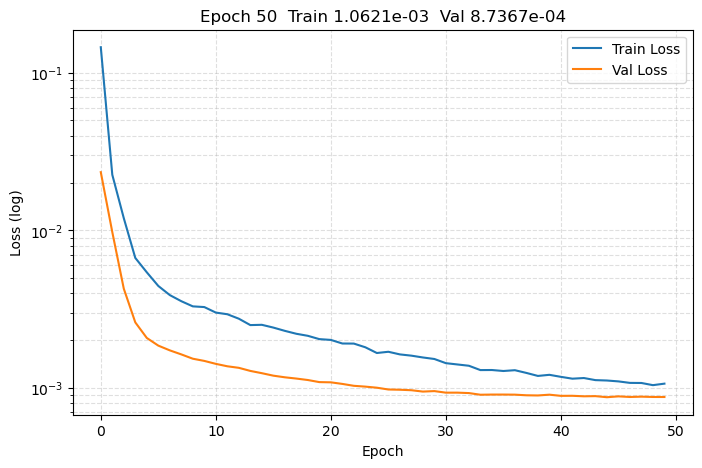

Epoch 50/50  train_loss=1.062062e-03  val_loss=8.736692e-04  time=0.6s
Training complete. Best val loss: 0.000870832840778998


In [17]:
# 训练循环（含物理重构损失与动态可视化）
model = MIMO_Conditioned_ANCNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)
epochs = 50
best_val = float('inf')
train_hist = []
val_hist = []

# 为方便访问，把 W 基底从 dataset 拿出来（已在 GPU 上）
W_components = full_ds.W_components  # shape (32, 4608), device
W_mean = full_ds.W_mean            # shape (4608,), device

for epoch in range(1, epochs + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    n_batches = 0
    for xb_p, xb_s, yb_c in train_loader:
        # xb_p: [B,4,129] (CPU tensor), xb_s: [B,32], yb_c: [B,32]
        xb_p = xb_p.to(device=device, dtype=torch.float32)
        xb_s = xb_s.to(device=device, dtype=torch.float32)
        yb_c = yb_c.to(device=device, dtype=torch.float32)

        optimizer.zero_grad()
        c_pred = model(xb_p, xb_s)  # [B,32]
        loss_c = F.mse_loss(c_pred, yb_c)

        # 物理解码：c @ W_components + W_mean -> [B,4608]
        W_pred_flat = torch.matmul(c_pred, W_components) + W_mean
        W_true_flat = torch.matmul(yb_c, W_components) + W_mean
        loss_w = F.mse_loss(W_pred_flat, W_true_flat)

        loss = loss_c + 0.1 * loss_w
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += float(loss.item())
        n_batches += 1

    train_loss = running_loss / max(1, n_batches)

    # 验证集评估
    model.eval()
    val_running = 0.0
    val_batches = 0
    with torch.no_grad():
        for xb_p, xb_s, yb_c in val_loader:
            xb_p = xb_p.to(device=device, dtype=torch.float32)
            xb_s = xb_s.to(device=device, dtype=torch.float32)
            yb_c = yb_c.to(device=device, dtype=torch.float32)

            c_pred = model(xb_p, xb_s)
            loss_c = F.mse_loss(c_pred, yb_c)
            W_pred_flat = torch.matmul(c_pred, W_components) + W_mean
            W_true_flat = torch.matmul(yb_c, W_components) + W_mean
            loss_w = F.mse_loss(W_pred_flat, W_true_flat)
            loss = loss_c + 0.1 * loss_w
            val_running += float(loss.item())
            val_batches += 1
    val_loss = val_running / max(1, val_batches)

    train_hist.append(train_loss)
    val_hist.append(val_loss)

    # 调度器根据验证集 loss 调整学习率
    scheduler.step(val_loss)

    # 动态可视化（清屏+绘图）
    clear_output(wait=True)
    plt.figure(figsize=(8,5))
    plt.plot(train_hist, label='Train Loss')
    plt.plot(val_hist, label='Val Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log)')
    plt.title(f'Epoch {epoch}  Train {train_loss:.4e}  Val {val_loss:.4e}')
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.show()

    # 保存最佳模型
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'best_mimo_anc_net.pth')
        print(f'>>> Saved best model at epoch {epoch}, val_loss={val_loss:.6e}')

    # 简要日志
    elapsed = time.time() - t0
    print(f'Epoch {epoch}/{epochs}  train_loss={train_loss:.6e}  val_loss={val_loss:.6e}  time={elapsed:.1f}s')

# 训练结束后，最后再保存一次（可选）
torch.save(model.state_dict(), 'final_mimo_anc_net.pth')
print('Training complete. Best val loss:', best_val)

In [19]:
# 推理示例：载入 best 模型并对验证集首个 batch 输出重构统计信息
m = MIMO_Conditioned_ANCNet().to(device)
m.load_state_dict(torch.load('best_mimo_anc_net.pth', map_location=device))
m.eval()
with torch.no_grad():
    for xb_p, xb_s, yb_c in val_loader:
        xb_p = xb_p.to(device=device, dtype=torch.float32)
        xb_s = xb_s.to(device=device, dtype=torch.float32)
        yb_c = yb_c.to(device=device, dtype=torch.float32)
        c_pred = m(xb_p, xb_s)
        W_pred_flat = torch.matmul(c_pred, full_ds.W_components) + full_ds.W_mean
        W_true_flat = torch.matmul(yb_c, full_ds.W_components) + full_ds.W_mean
        # 计算一些统计量
        mse_flat = F.mse_loss(W_pred_flat, W_true_flat).item()
        print('Example batch reconstruction MSE (flat):', mse_flat)
        # 将第一个样本 reshape 为 (3,3,512) 并打印能量统计
        W0 = W_pred_flat[0].cpu().numpy().reshape(3,3,512)
        print('W0 shape (sec,ref,L):', W0.shape, 'norm:', np.linalg.norm(W0))
        break

Example batch reconstruction MSE (flat): 4.912007170787547e-06
W0 shape (sec,ref,L): (3, 3, 512) norm: 0.2261746


C:\Windows\Temp\ipykernel_27488\3144486362.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load('best_mimo_anc_net.pth', map_location=device))


**说明与使用建议：**
- 本 Notebook 假设 DataLoader 使用 `num_workers=0`（以避免在 worker 进程中复制 GPU 张量）。若需加速，可将 `W_components`/`W_mean` 以共享内存或单独进程加载，然后在训练循环中将其转到设备。
- 若训练在 GPU 上发生 OOM，可通过减小 `batch_size` 或把 `W_components` 保留在 CPU 并在每个 batch 前移动到 GPU（trade-off）。
- 为了可重复性，请确保在运行前固定随机种子（已在顶部设置）。

需要我现在在这个环境里运行 Notebook 的训练吗？（注意：完整训练 100 epochs 需要较长时间和 GPU 资源）